# AI Cybersecurity Machine Learning project 

## ~Explication project

## ~Importation des bibliothèques

In [40]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation
from sklearn.metrics import (confusion_matrix,classification_report,accuracy_score, precision_score,recall_score,f1_score,roc_auc_score)

## ~Chargement du dataset

In [41]:
df=pd.read_csv('cicids2017_binary_balanced.csv')
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack_Binary
0,80,5121659,3,12,6,0,4.0,3.464102,0,0,...,17922,2,20,0.0,0,0,0.0,0,0,0
1,53,128476,1,53,53,53,53.0,0.000000,116,116,...,-1,0,32,0.0,0,0,0.0,0,0,0
2,53,23701,1,53,53,53,53.0,0.000000,69,69,...,-1,0,32,0.0,0,0,0.0,0,0,0
3,54549,4,2,0,0,0,0.0,0.000000,0,0,...,-1,0,20,0.0,0,0,0.0,0,0,0
4,53,252129,1,58,58,58,58.0,0.000000,202,202,...,-1,0,32,0.0,0,0,0.0,0,0,0


## ~EDA / Data Exploration

### Analyse de forme

In [42]:
df.shape

(850970, 53)

In [43]:
df["Attack_Binary"].value_counts()

Attack_Binary
0    425694
1    425276
Name: count, dtype: int64

In [44]:
df["Attack_Binary"].value_counts(normalize=True) * 100 # we have the same number of elements in the 2 target class 

Attack_Binary
0    50.02456
1    49.97544
Name: proportion, dtype: float64

### Number of rows & columns

In [45]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 850970
Number of columns: 53


### Type of variables

In [46]:
df.dtypes.value_counts()
#int64      33
#float64    20

int64      33
float64    20
Name: count, dtype: int64

### Check missing values

In [47]:
df.isnull().sum().sum() # 0 NAN

np.int64(0)

### Check infinite values

In [48]:
np.isinf(df.select_dtypes(include=np.number)).sum().sum() # no inf

np.int64(0)

### Quick dataset summary

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,850970.0,6.021643e+03,1.581210e+04,0.000000e+00,80.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,850970.0,2.530810e+07,4.069823e+07,-1.200000e+01,232.000000,152108.000000,6.114048e+07,1.200000e+08
Total Fwd Packets,850970.0,7.893245e+00,6.087964e+02,1.000000e+00,2.000000,3.000000,7.000000e+00,2.177970e+05
Total Length of Fwd Packets,850970.0,4.512349e+02,4.644648e+03,0.000000e+00,12.000000,58.000000,3.470000e+02,1.288022e+06
Fwd Packet Length Max,850970.0,1.989528e+02,6.103196e+02,0.000000e+00,6.000000,36.000000,3.220000e+02,2.482000e+04
Fwd Packet Length Min,850970.0,1.224504e+01,5.075347e+01,0.000000e+00,0.000000,0.000000,6.000000e+00,2.065000e+03
Fwd Packet Length Mean,850970.0,5.084897e+01,1.585663e+02,0.000000e+00,6.000000,32.000000,5.200000e+01,5.940857e+03
Fwd Packet Length Std,850970.0,7.059986e+01,2.379736e+02,0.000000e+00,0.000000,0.000000,1.170675e+02,7.125597e+03
Bwd Packet Length Max,850970.0,2.048322e+03,3.027639e+03,0.000000e+00,6.000000,113.000000,4.344000e+03,1.168000e+04
Bwd Packet Length Min,850970.0,2.656162e+01,5.954295e+01,0.000000e+00,0.000000,0.000000,6.000000e+00,1.983000e+03


### Check duplicated rows

In [50]:
df.duplicated().sum() # 965 duplicates

np.int64(965)

In [51]:
df = df.drop_duplicates()

In [52]:
df.duplicated().sum() 

np.int64(0)

In [53]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 850005
Number of columns: 53


### First visualization — Attack distribution

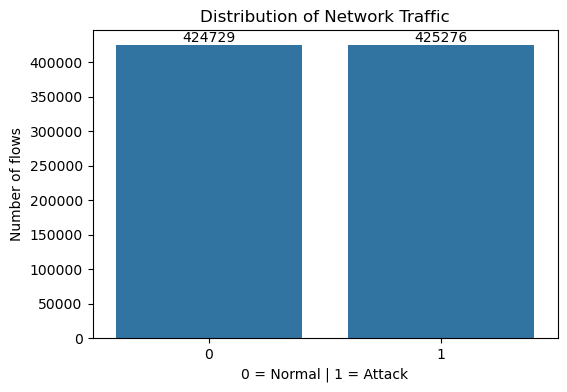

In [54]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Attack_Binary")

plt.title("Distribution of Network Traffic")
plt.xlabel("0 = Normal | 1 = Attack")
plt.ylabel("Number of flows")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Target / Class Distribution

In [55]:
df["Attack_Binary"].value_counts()

Attack_Binary
1    425276
0    424729
Name: count, dtype: int64

In [56]:
df["Attack_Binary"].value_counts(normalize=True) * 100

Attack_Binary
1    50.032176
0    49.967824
Name: proportion, dtype: float64

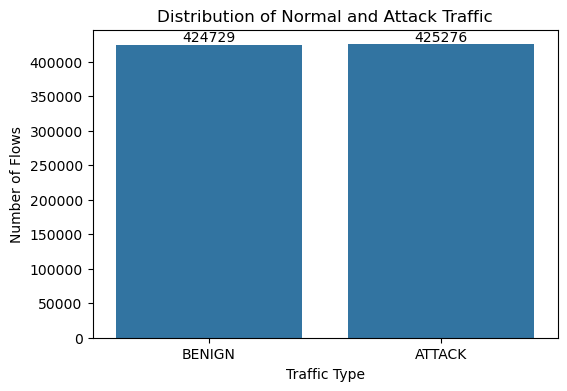

In [57]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Attack_Binary")

plt.title("Distribution of Normal and Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Flows")

plt.xticks([0, 1], ["BENIGN", "ATTACK"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Analyze Variables Separately (choose representative network-flow feature)

In [58]:
selected_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
    "Flow IAT Mean",
    "Average Packet Size"
]

In [59]:
df[selected_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,850005.0,2.533681e+07,4.071239e+07,-12.0,234.000000,153036.000000,6.120858e+07,1.200000e+08
Total Fwd Packets,850005.0,7.900115e+00,6.091419e+02,1.0,2.000000,3.000000,7.000000e+00,2.177970e+05
Total Length of Fwd Packets,850005.0,4.516742e+02,4.647266e+03,0.0,12.000000,58.000000,3.470000e+02,1.288022e+06
Flow Bytes/s,850005.0,8.710524e+05,2.037022e+07,-12000000.0,120.149895,1761.735500,8.571429e+04,2.071000e+09
Flow Packets/s,850005.0,3.505588e+04,1.664723e+05,-2000000.0,0.396735,33.019646,1.498127e+04,3.000000e+06
Packet Length Mean,850005.0,3.374656e+02,4.412354e+02,0.0,6.000000,70.600000,7.936667e+02,2.920000e+03
Packet Length Std,850005.0,6.655930e+02,9.628513e+02,0.0,2.309401,42.722360,1.460760e+03,4.731523e+03
Flow IAT Mean,850005.0,2.379079e+06,5.407310e+06,-12.0,103.000000,47791.000000,2.909876e+06,1.200000e+08
Average Packet Size,850005.0,3.719389e+02,4.841266e+02,0.0,7.200000,89.679245,8.498571e+02,3.337143e+03


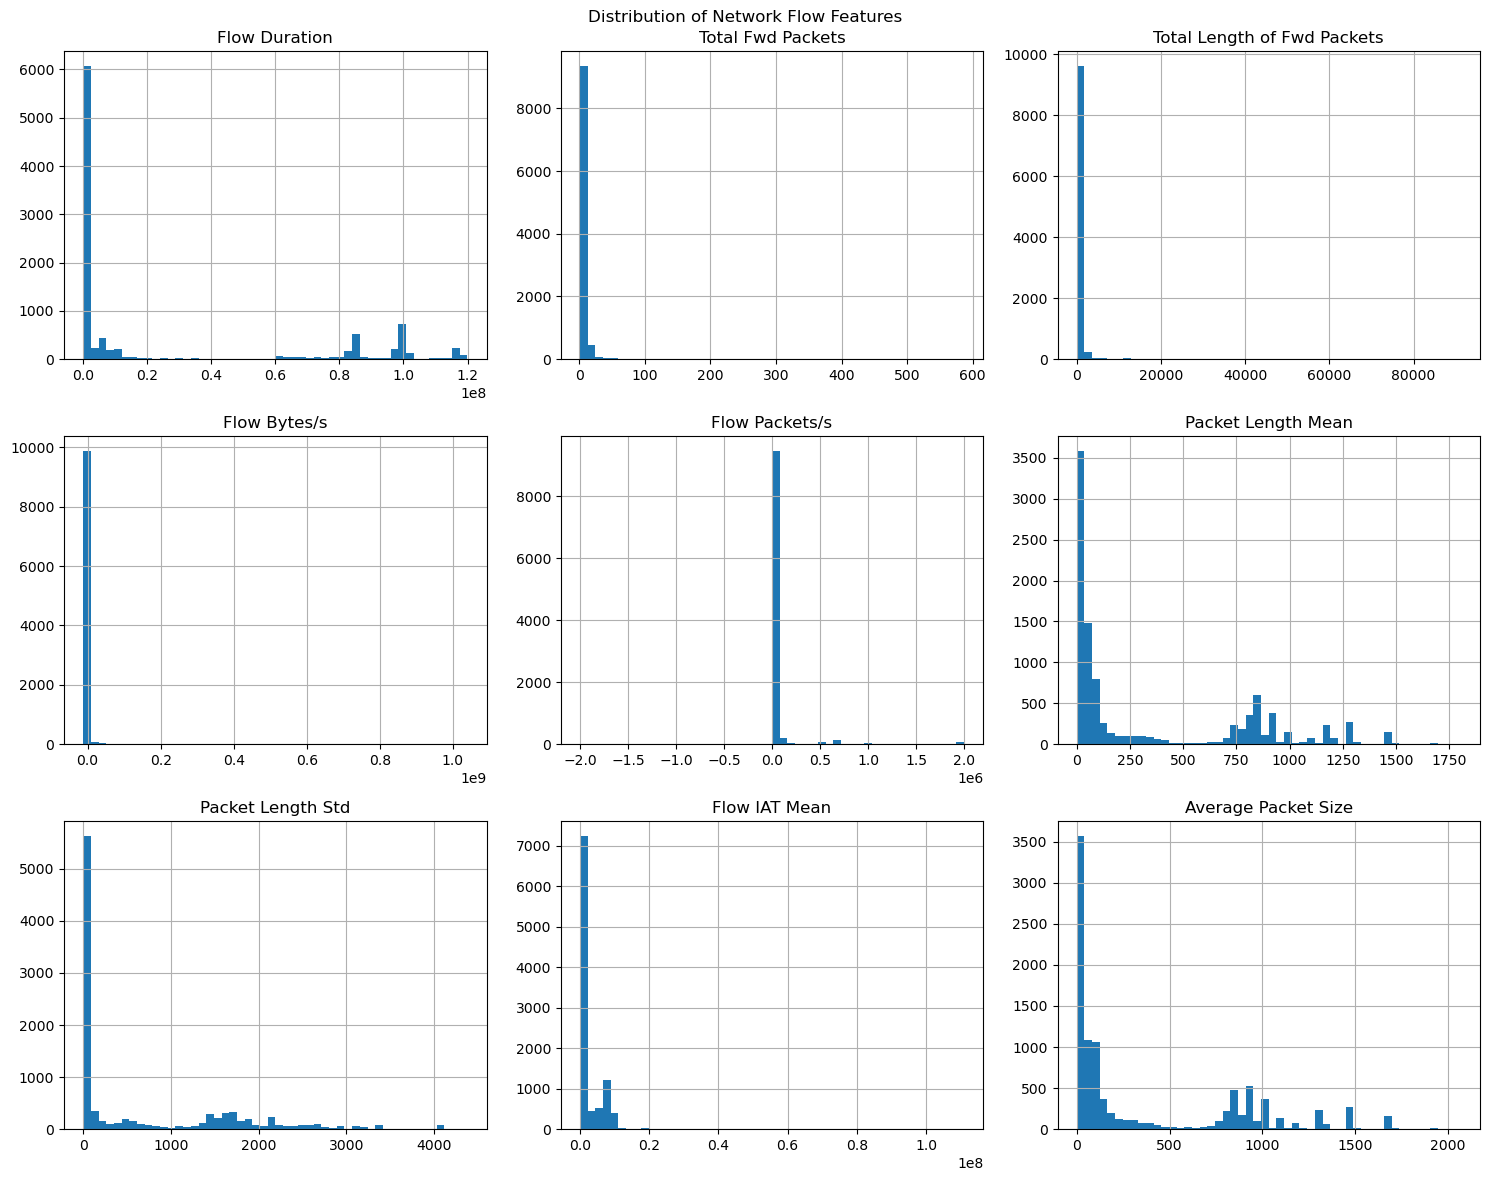

In [60]:
# histogram
sample_df = df[selected_features].sample(n=10000,random_state=42)

sample_df.hist(figsize=(15, 12),bins=50)

plt.suptitle("Distribution of Network Flow Features")

plt.tight_layout()
plt.show()

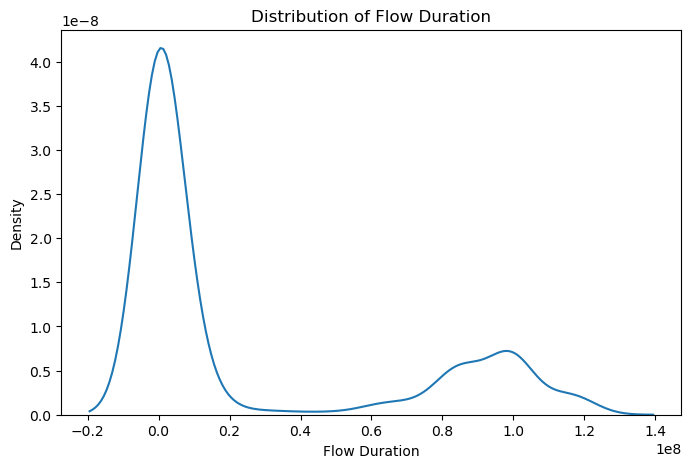

In [61]:
# KDE — KDE shows the estimated distribution more smoothly
plt.figure(figsize=(8, 5))

sns.kdeplot(data=sample_df, x="Flow Duration")

plt.title("Distribution of Flow Duration")
plt.xlabel("Flow Duration")
plt.ylabel("Density")

plt.show()

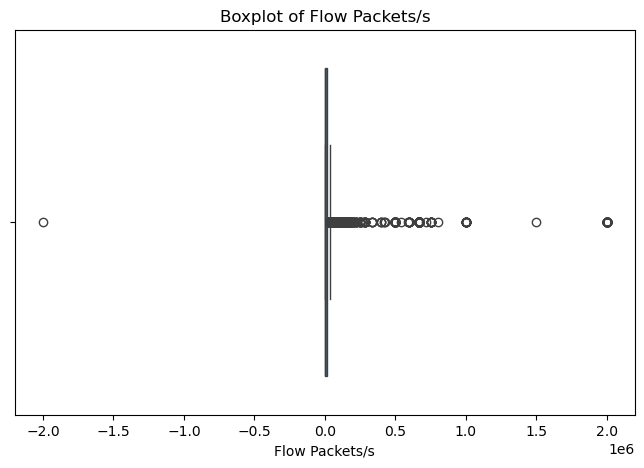

In [62]:
# Boxplots
plt.figure(figsize=(8, 5))

sns.boxplot(data=sample_df,x="Flow Packets/s")

plt.title("Boxplot of Flow Packets/s")
plt.show()

# a lot of outliers can be a sign of attack (Unusual network behavior/Potential anomaly)

### Analyze Relationships Between Features

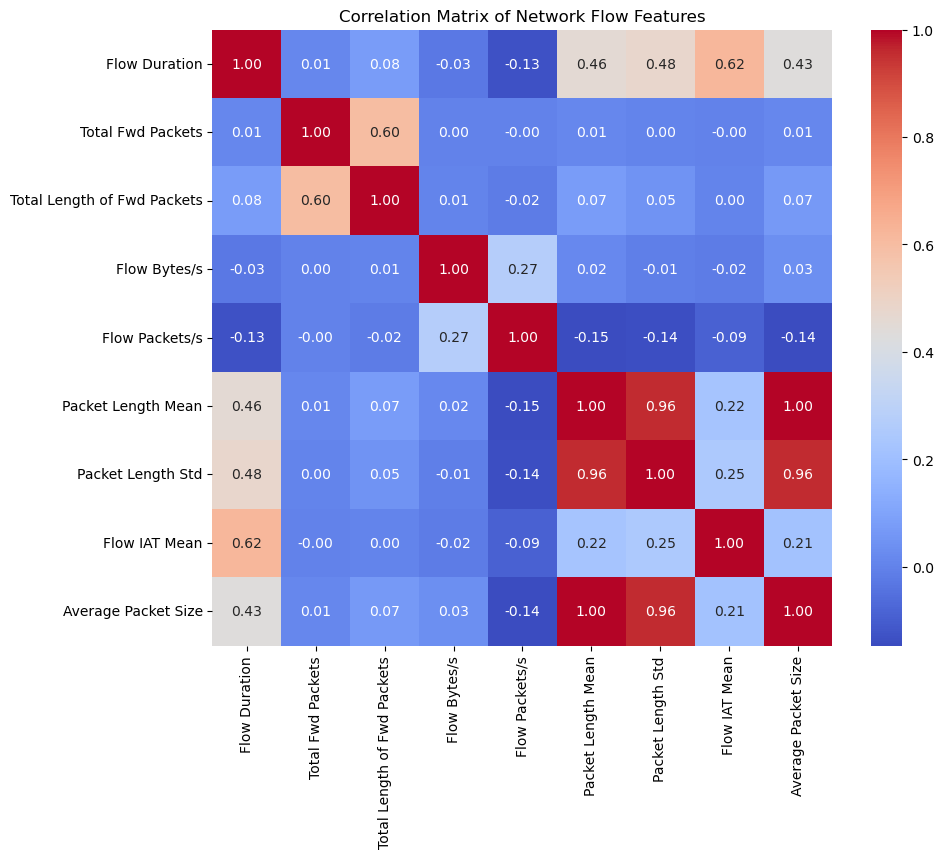

In [63]:
#Correlation matrix
correlation = df[selected_features].corr()

#visualise
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Network Flow Features")

plt.show()

In [64]:
#Find highly correlated features automatically
corr_matrix = df.drop(columns=["Attack_Binary"]).corr()

high_corr = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr[high_corr > 0.90]

Total Length of Fwd Packets  Subflow Fwd Bytes         1.000000
Flow IAT Max                 Fwd IAT Max               0.999391
Flow Duration                Fwd IAT Total             0.999247
Packet Length Mean           Average Packet Size       0.998925
Flow IAT Max                 Idle Max                  0.996351
Fwd IAT Max                  Idle Max                  0.996089
Idle Mean                    Idle Min                  0.989889
                             Idle Max                  0.989688
Bwd Packet Length Max        Bwd Packet Length Std     0.988349
Flow IAT Max                 Idle Mean                 0.986120
Max Packet Length            Packet Length Std         0.985789
Fwd IAT Max                  Idle Mean                 0.985613
Bwd Packet Length Max        Max Packet Length         0.983914
Bwd Packet Length Std        Packet Length Std         0.975403
Bwd Packet Length Max        Packet Length Std         0.972773
Bwd Packet Length Std        Max Packet 

Why this matters for our Autoencoder: 
* Two features contain very similar information.
* That doesn't automatically mean we must delete one.

### ~Outliers

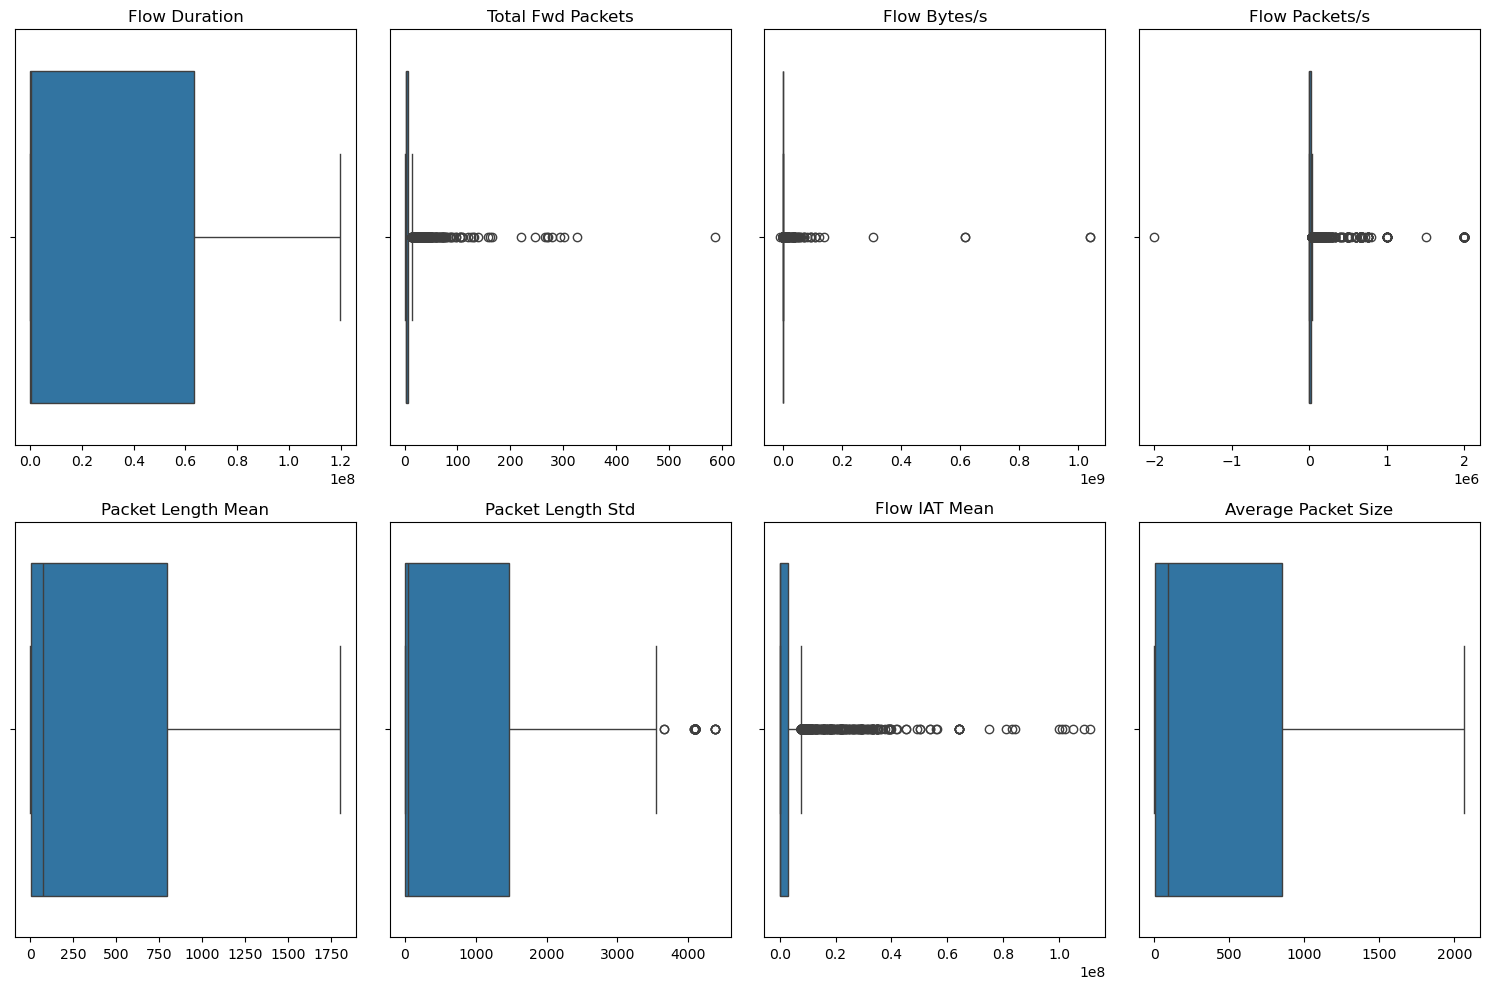

In [65]:
# Check outliers with boxplots

# Sample for visualization
sample_df = df.sample(n=10000, random_state=42)

# Features to inspect
outlier_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
    "Flow IAT Mean",
    "Average Packet Size"
]

# Boxplots
plt.figure(figsize=(15, 10))

for i, feature in enumerate(outlier_features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(data=sample_df, x=feature)
    plt.title(feature)
    plt.xlabel("")

plt.tight_layout()
plt.show()

### ~Data Cleaning

In [66]:
# Missing values — NaN
df.isnull().sum().sum()

np.int64(0)

In [67]:
# Duplicates
df.duplicated().sum()

np.int64(0)

In [68]:
# Negative values -- Many network-flow measurements should not be negative.
numeric_features = df.drop(columns=["Attack_Binary"])

negative_values = (numeric_features < 0).sum()

negative_values[negative_values > 0]

Flow Duration                  14
Flow Bytes/s                   10
Flow Packets/s                 14
Flow IAT Mean                  14
Flow IAT Max                   14
Flow IAT Min                  706
Fwd IAT Min                    17
Fwd Header Length               7
Bwd Header Length               5
Init_Win_bytes_forward     184266
Init_Win_bytes_backward    296188
min_seg_size_forward            7
dtype: int64

In [69]:
# Constant columns
constant_columns = [
    column for column in df.columns
    if df[column].nunique() <= 1]

constant_columns

[]

In [70]:
df.drop(columns=constant_columns, inplace=True)

In [71]:
# First obvious redundant feature
df.drop(columns=["Subflow Fwd Bytes"], inplace=True)

### Remove unnecessary columns

The important rule is:

* Attack_Binary is the answer/label, not an input feature.
* Your Autoencoder must learn what normal traffic looks like without seeing whether a flow is an attack.

In [72]:
# Separate X and y

# Target / label
y = df["Attack_Binary"]

# Features used by the Autoencoder
X = df.drop(columns=["Attack_Binary"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (850005, 51)
y shape: (850005,)


In [73]:
# Check the columns

print("Number of features:", X.shape[1])
print("\nFeatures:")
print(X.columns.tolist())  # leave just Number of features: 51

Number of features: 51

Features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle Mean', 'I

## Feature Engineering

In [74]:
# The dataset already contains engineered
# network-flow features.
# No additional features are created for V1.

print("\nFeature Engineering:")
print("Using existing network-flow features.")
print("No new features created for Version 1.")


Feature Engineering:
Using existing network-flow features.
No new features created for Version 1.


## Preprocessing 

### Features Scaling -- Train/Test Split — BUT differently

Important: avoid data leakage

* For your anomaly-detection project, we should fit the scaler only on normal training data.
* Because the Autoencoder is supposed to learn the distribution of normal traffic. 

### Train/Test Split — BUT differently
* ur Autoencoder should learn:  "This is what normal network traffic looks like."

* Training  Use only:   Attack_Binary == 0

* So:BENIGN BENIGN BENIGN =>Autoencoder =>Learns normal patterns

* Testing Use both: BENIGN + ATTACK

##### NOrmalisation
* fit = learn mean + standard deviation
* transform = apply the learned scaling

###  Autoencoder Architecture

### Compile the Autoencoder

### Training the Autoencoder

### Choose Anomaly Threshold(seuil)

* explaination :
this threshold optimizer is picking the lowest possible threshold because your threshold-finding set is 67% attack / 33% normal — so the "always predict attack" solution gets F1 ≈ 0.80 on that mix, which is exactly the F1 your optimizer found (0.8002). The optimizer isn't improving the model; it's just matching the baseline of "always attack.

## ISOLATION FOREST

In [75]:
# ============================================================
# ISOLATION FOREST — simple alternative to the Autoencoder
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

# Train ONLY on normal data (same rule as your autoencoder)
iso = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_s)

# Score: -decision_function => higher = more anomalous
thresh_score = -iso.decision_function(X_thresh_s)
test_score   = -iso.decision_function(X_test_s)

# Pick threshold on the threshold set by maximizing F1
best_f1, best_t = -1, 0
for t in np.linspace(thresh_score.min(), thresh_score.max(), 500):
    pred = (thresh_score > t).astype(int)
    if pred.sum() == 0 or pred.sum() == len(pred):
        continue
    f1 = f1_score(y_thresh, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print(f"Isolation Forest threshold: {best_t:.6f}  (F1 on thresh set: {best_f1:.4f})")

# Final evaluation on test set
y_pred_iso = (test_score > best_t).astype(int)
cm = confusion_matrix(y_test, y_pred_iso)

print("\nConfusion Matrix:\n", cm)
print(f"\nAccuracy : {accuracy_score(y_test, y_pred_iso):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_iso):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_iso):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_iso):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_score):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, test_score):.4f}")
print("\n", classification_report(y_test, y_pred_iso, target_names=["Normal", "Attack"]))

Isolation Forest threshold: -0.143621  (F1 on thresh set: 0.8763)

Confusion Matrix:
 [[ 36402  27308]
 [ 15962 281732]]

Accuracy : 0.8803
Precision: 0.9116
Recall   : 0.9464
F1-score : 0.9287
ROC-AUC  : 0.8390
PR-AUC   : 0.9550

               precision    recall  f1-score   support

      Normal       0.70      0.57      0.63     63710
      Attack       0.91      0.95      0.93    297694

    accuracy                           0.88    361404
   macro avg       0.80      0.76      0.78    361404
weighted avg       0.87      0.88      0.88    361404



## One-Class SVM

In [76]:
# ============================================================
# ONE-CLASS SVM
# ============================================================
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
import numpy as np

# SVM is slow on huge data — subsample 30k normals to train
n_sub = min(30000, len(X_train_s))
idx = np.random.RandomState(42).choice(len(X_train_s), n_sub, replace=False)
X_train_sub = X_train_s[idx]

ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
ocsvm.fit(X_train_sub)

# Score: -decision_function => higher = more anomalous
thresh_score = -ocsvm.decision_function(X_thresh_s)
test_score   = -ocsvm.decision_function(X_test_s)

# Pick threshold by maximizing F1 on the threshold set
best_f1, best_t = -1, 0
for t in np.linspace(thresh_score.min(), thresh_score.max(), 500):
    pred = (thresh_score > t).astype(int)
    if pred.sum() == 0 or pred.sum() == len(pred):
        continue
    f1 = f1_score(y_thresh, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print(f"One-Class SVM threshold: {best_t:.6f}  (F1 on thresh set: {best_f1:.4f})")

y_pred_ocsvm = (test_score > best_t).astype(int)
cm = confusion_matrix(y_test, y_pred_ocsvm)

print("\nConfusion Matrix:\n", cm)
print(f"\nAccuracy : {accuracy_score(y_test, y_pred_ocsvm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ocsvm):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_ocsvm):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_ocsvm):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_score):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, test_score):.4f}")
print("\n", classification_report(y_test, y_pred_ocsvm, target_names=["Normal", "Attack"]))

One-Class SVM threshold: -16.417385  (F1 on thresh set: 0.8502)

Confusion Matrix:
 [[ 31598  32112]
 [ 22291 275403]]

Accuracy : 0.8495
Precision: 0.8956
Recall   : 0.9251
F1-score : 0.9101
ROC-AUC  : 0.8288
PR-AUC   : 0.9600

               precision    recall  f1-score   support

      Normal       0.59      0.50      0.54     63710
      Attack       0.90      0.93      0.91    297694

    accuracy                           0.85    361404
   macro avg       0.74      0.71      0.72    361404
weighted avg       0.84      0.85      0.84    361404



## AutoEncoder with Pytorch

Train (normal) : (297310, 51)
Thresh (N+A)   : (191291, 51) | N = 63709 A = 127582
Test   (N+A)   : (361404, 51) | N = 63710 A = 297694

Scaled mean: -0.0
Scaled std : 1.0


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 32)                  │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 51)                  │           1,683 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,699 (18.36 KB)

 Trainable params: 4,699 (18.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.3757 - val_loss: 0.1370
Epoch 2/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.2189 - val_loss: 0.1008
Epoch 3/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.1950 - val_loss: 0.0926
Epoch 4/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.1744 - val_loss: 0.0923
Epoch 5/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.1466 - val_loss: 0.0818
Epoch 6/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.1554 - val_loss: 0.0811
Epoch 7/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.1351 - val_loss: 0.0733
Epoch 8/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.1269 - val_loss: 0.0689
Epoch 9/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.1233 - val_loss: 0.0679
Epoch 10/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.1156 - val_loss: 0.0700
Epoch 11/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.1099 - val_loss: 0.0675
Epoch 12/50
1046/1046 ━━━━━━

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



               precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     63710
      Attack       0.82      1.00      0.90    297694

    accuracy                           0.82    361404
   macro avg       0.41      0.50      0.45    361404
weighted avg       0.68      0.82      0.74    361404



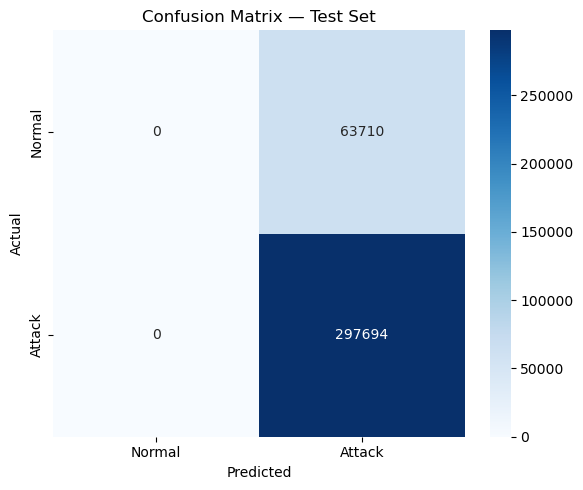

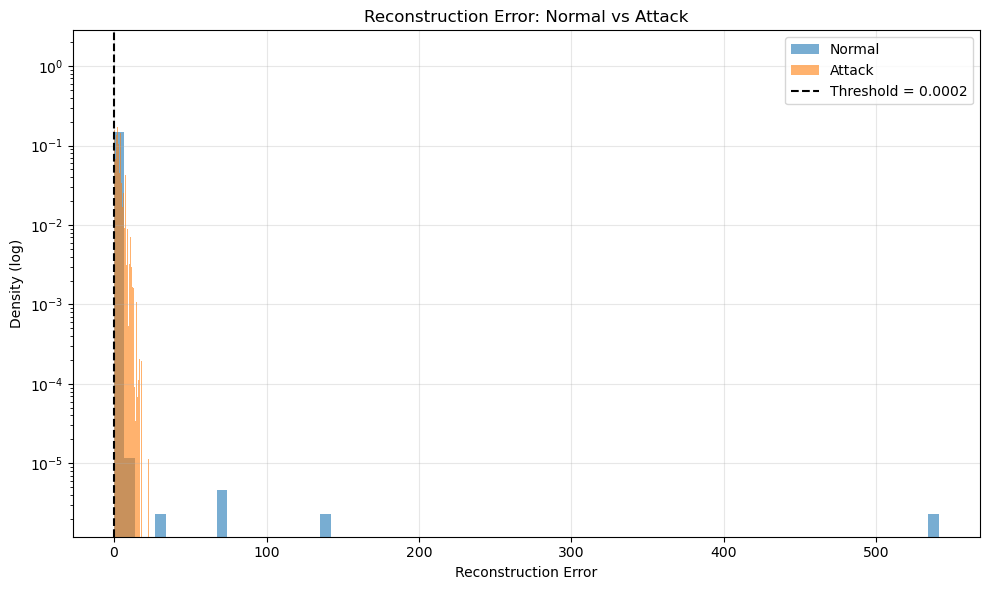

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# SPLIT
# ============================================================
X_normal = X[y == 0].reset_index(drop=True)
X_attack = X[y == 1].reset_index(drop=True)

# Normal -> train + threshold-val + test-normal
X_train, X_temp = train_test_split(X_normal, test_size=0.30, random_state=42)
X_thresh_normal, X_test_normal = train_test_split(X_temp, test_size=0.50, random_state=42)

# Attack -> threshold-attack + test-attack
X_thresh_attack, X_test_attack = train_test_split(X_attack, test_size=0.70, random_state=42)

# Threshold-finding set = normal + attack (with labels)
X_thresh = pd.concat([X_thresh_normal, X_thresh_attack], axis=0, ignore_index=True)
y_thresh = pd.concat([
    pd.Series(0, index=range(len(X_thresh_normal))),
    pd.Series(1, index=range(len(X_thresh_attack)))
], ignore_index=True)

# Final test set = normal + attack (with labels)
X_test = pd.concat([X_test_normal, X_test_attack], axis=0, ignore_index=True)
y_test = pd.concat([
    pd.Series(0, index=range(len(X_test_normal))),
    pd.Series(1, index=range(len(X_test_attack)))
], ignore_index=True)

print("Train (normal) :", X_train.shape)
print("Thresh (N+A)   :", X_thresh.shape, "| N =", len(X_thresh_normal), "A =", len(X_thresh_attack))
print("Test   (N+A)   :", X_test.shape,   "| N =", len(X_test_normal),   "A =", len(X_test_attack))


# ============================================================
# SCALING (StandardScaler, fit on train only)
# ============================================================
scaler = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_thresh_s = scaler.transform(X_thresh)
X_test_s   = scaler.transform(X_test)

print("\nScaled mean:", X_train_s.mean().round(6))
print("Scaled std :", X_train_s.std().round(6))


# ============================================================
# SIMPLE AUTOENCODER (your original architecture)
# ============================================================
input_dim = X_train_s.shape[1]

autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)), # encoder
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8,  activation="relu"), # bottleneck - latent space
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(input_dim, activation="linear"), # decoder
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


# ============================================================
# TRAIN with early stopping
# ============================================================
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

# train the autoencoder
history = autoencoder.fit(
    X_train_s, X_train_s,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1
)


# ============================================================
# RECONSTRUCTION ERRORS
# ============================================================
def rec_error(Xs, model):
    recon = model.predict(Xs, batch_size=1024, verbose=0)
    return np.mean(np.square(Xs - recon), axis=1)

thresh_errors = rec_error(X_thresh_s, autoencoder)
test_errors   = rec_error(X_test_s,   autoencoder)

print("\nThresh errors — normal mean:", thresh_errors[y_thresh == 0].mean().round(4))
print("Thresh errors — attack mean:", thresh_errors[y_thresh == 1].mean().round(4))


# ============================================================
# FIND THRESHOLD ON THRESH SET (not on test!)
# ============================================================
best_f1, best_thresh = -1, 0
for t in np.linspace(thresh_errors.min(), thresh_errors.max(), 500):
    pred = (thresh_errors > t).astype(int)
    if pred.sum() == 0 or pred.sum() == len(pred):
        continue
    f1 = f1_score(y_thresh, pred)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"\nChosen threshold: {best_thresh:.6f}")
print(f"F1 on threshold set: {best_f1:.4f}")


# ============================================================
# FINAL EVALUATION ON TEST
# ============================================================
y_pred = (test_errors > best_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print(f"\nAccuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_errors):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, test_errors):.4f}")

print("\n", classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))


# ============================================================
# PLOTS
# ============================================================
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
plt.hist(test_errors[y_test == 0], bins=80, alpha=0.6, label="Normal", density=True)
plt.hist(test_errors[y_test == 1], bins=80, alpha=0.6, label="Attack", density=True)
plt.axvline(best_thresh, color="black", linestyle="--", label=f"Threshold = {best_thresh:.4f}")
plt.yscale("log")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density (log)")
plt.title("Reconstruction Error: Normal vs Attack")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); 
plt.show()

## Save the model

In [78]:
import os
import joblib

os.makedirs("models", exist_ok=True)

# 1. Scaler
joblib.dump(scaler, "models/scaler.pkl")

# 2. Autoencoder + threshold
autoencoder.save("models/autoencoder.keras")
joblib.dump(float(best_thresh), "models/autoencoder_threshold.pkl")

# 3. One-Class SVM + threshold
joblib.dump(ocsvm, "models/one_class_svm.pkl")
joblib.dump(float(best_t), "models/one_class_svm_threshold.pkl")

# 4. Isolation Forest + threshold
joblib.dump(iso, "models/isolation_forest.pkl")
joblib.dump(float(best_t), "models/isolation_forest_threshold.pkl")

['models/isolation_forest_threshold.pkl']